<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #01579b 0%, #0277bd 50%, #0288d1 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 1</h1>
  <h2 style="color:#b3e5fc; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Токенизация және Мəтінді Алдын Ала Өңдеу</h2>
  <p style="color:#e1f5fe; font-size:1em; margin:0;">Tokenization · Normalization · Stemming · Lemmatization · Subword · Vocabulary</p>
</div>

## Кіріспе

**Токенизация** — кез келген NLP жобасының бірінші қадамы. Мəтінді машина оқи алатын бірліктерге — токендерге — бөлу процесі. Токен сөз, символ, субсөз немесе сөйлем болуы мүмкін.

Нейрондық желілер мəтінді тікелей оқи алмайды. Сондықтан əр токен санға (индекске) айналдырылады, содан кейін векторға. Токенизация сапасы бүкіл NLP жүйесінің сапасына тікелей əсер етеді.

Бұл зертханада қазақ жəне ағылшын мəтіндерімен жұмыс жасай отырып, əртүрлі токенизация тəсілдерін салыстырасыз.

## Оқу Мақсаттары

- Сөз, символ жəне сөйлем деңгейінде токенизация жасай аласыз
- Мəтінді нормализациялай аласыз (кіші əріп, тыныш белгілерді алу, стоп-сөздер)
- Стемминг пен лемматизацияның айырмасын практикада байқай аласыз
- Subword токенизациясының (BPE принципі) мəнін түсінесіз
- Vocabulary жасап, мəтінді индекстерге айналдыра аласыз
- Keras Tokenizer жəне NLTK арқылы токенизация жасай аласыз

**Болжалды орындалу уақыты: 60 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import re
import string
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLTK — табиғи тілді өңдеу кітапханасы
import nltk
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize, TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

# TensorFlow Keras Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Кітапханалар жүктелді.")

Кітапханалар жүктелді.


In [2]:
# ============================================================
### TODO ###
# Жұмыс деректерін анықтаңыз.
# sample_texts тізімін 5 ағылшын сөйлемімен толтырыңыз.
# Мысалы: технология, жаратылыстану немесе кез келген тақырып.
# ============================================================
sample_texts = [
    "Artificial intelligence is transforming many industries.",
    "Natural language processing helps computers understand text.",
    "Machine learning algorithms learn patterns from data.",
    "Deep neural networks achieve remarkable performance.",
    "Tokenization converts text into meaningful units."
]

# Мысал: сол мəтін (əдепкі мəн)
if any(s == ___ for s in sample_texts):
    sample_texts = [
        "Natural language processing is a fascinating field of artificial intelligence.",
        "Machine learning models can understand and generate human language.",
        "Tokenization is the first step in any NLP pipeline.",
        "Deep learning has revolutionized how we process text data!",
        "BERT and GPT are powerful transformer-based language models."
    ]

print(f"{len(sample_texts)} сөйлем жүктелді.")
for i, t in enumerate(sample_texts):
    print(f"  {i+1}: {t}")

5 сөйлем жүктелді.
  1: Artificial intelligence is transforming many industries.
  2: Natural language processing helps computers understand text.
  3: Machine learning algorithms learn patterns from data.
  4: Deep neural networks achieve remarkable performance.
  5: Tokenization converts text into meaningful units.


## 2-бөлім: Сөз Деңгейіндегі Токенизация

Ең кең тараған тəсіл — мəтінді бос орындар мен тыныc белгілер бойынша сөздерге бөлу.

In [3]:
text = sample_texts[0]
print("Түпнұсқа мəтін:")
print(text)
print()

Түпнұсқа мəтін:
Artificial intelligence is transforming many industries.



In [4]:
# ============================================================
### TODO ###
# Мəтінді 3 əдіспен токенизациялаңыз:
#   1) Python .split() арқылы қарапайым бөлу
#   2) re.findall(r'\b\w+\b', text) — regex арқылы
#   3) nltk.word_tokenize(text) — NLTK арқылы
# Əр əдістің нəтижесін жəне токендер санын шығарыңыз.
# ============================================================
tokens_split  = text.split()
tokens_regex  = re.findall(r'\b\w+\b', text)
tokens_nltk   = word_tokenize(text)

print(f"split()        : {len(tokens_split):>3} токен → {tokens_split}")
print(f"regex          : {len(tokens_regex):>3} токен → {tokens_regex}")
print(f"word_tokenize(): {len(tokens_nltk):>3} токен → {tokens_nltk}")

split()        :   6 токен → ['Artificial', 'intelligence', 'is', 'transforming', 'many', 'industries.']
regex          :   6 токен → ['Artificial', 'intelligence', 'is', 'transforming', 'many', 'industries']
word_tokenize():   7 токен → ['Artificial', 'intelligence', 'is', 'transforming', 'many', 'industries', '.']


In [5]:
# ============================================================
### TODO ###
# Тыныш белгілерімен бірге жазылған мəтінді сынаңыз.
# tricky_text = "It's a well-known fact: NLP isn't easy, but it's worth it!"
# Үш əдіспен токенизациялап, айырмасын байқаңыз.
# ============================================================
tricky_text = "It's a well-known fact: NLP isn't easy, but it's worth it!"

t_split = tricky_text.split()
t_regex = re.findall(r"\b\w+(?:'\w+)?\b", tricky_text)
t_nltk = word_tokenize(tricky_text)

print("Күрделі мəтін:", tricky_text)
print(f"split()  ({len(t_split):>2}): {t_split}")
print(f"regex    ({len(t_regex):>2}): {t_regex}")
print(f"NLTK     ({len(t_nltk):>2}): {t_nltk}")

Күрделі мəтін: It's a well-known fact: NLP isn't easy, but it's worth it!
split()  (11): ["It's", 'a', 'well-known', 'fact:', 'NLP', "isn't", 'easy,', 'but', "it's", 'worth', 'it!']
regex    (12): ["It's", 'a', 'well', 'known', 'fact', 'NLP', "isn't", 'easy', 'but', "it's", 'worth', 'it']
NLTK     (17): ['It', "'s", 'a', 'well-known', 'fact', ':', 'NLP', 'is', "n't", 'easy', ',', 'but', 'it', "'s", 'worth', 'it', '!']


## 3-бөлім: Символ жəне Сөйлем Деңгейіндегі Токенизация

In [6]:
# ============================================================
### TODO ###
# sample_texts тізімін бір мəтінге біріктіріңіз (join арқылы).
# sent_tokenize() арқылы сөйлемдерге бөліңіз.
# Əр сөйлемді нөмірімен шығарыңыз.
# ============================================================
full_text = ' '.join(sample_texts)
sentences = sent_tokenize(full_text)

print(f"Жалпы сөйлем саны: {len(sentences)}")
for i, sent in enumerate(sentences):
    print(f"  {i+1}: {sent}")

Жалпы сөйлем саны: 5
  1: Artificial intelligence is transforming many industries.
  2: Natural language processing helps computers understand text.
  3: Machine learning algorithms learn patterns from data.
  4: Deep neural networks achieve remarkable performance.
  5: Tokenization converts text into meaningful units.


In [7]:
# Символ деңгейіндегі токенизация
char_tokens = list(text)

print(f"Символ токендері ({len(char_tokens)} дана):")
print(char_tokens)

# Əріп, бос орын, тыныш белгілерді санаймыз
letters = [c for c in char_tokens if c.isalpha()]
spaces  = [c for c in char_tokens if c == ' ']
puncts  = [c for c in char_tokens if c in string.punctuation]

print(f"\nƏріптер:        {len(letters)}")
print(f"Бос орындар:    {len(spaces)}")
print(f"Тыныш белгілер: {len(puncts)}")

Символ токендері (56 дана):
['A', 'r', 't', 'i', 'f', 'i', 'c', 'i', 'a', 'l', ' ', 'i', 'n', 't', 'e', 'l', 'l', 'i', 'g', 'e', 'n', 'c', 'e', ' ', 'i', 's', ' ', 't', 'r', 'a', 'n', 's', 'f', 'o', 'r', 'm', 'i', 'n', 'g', ' ', 'm', 'a', 'n', 'y', ' ', 'i', 'n', 'd', 'u', 's', 't', 'r', 'i', 'e', 's', '.']

Əріптер:        50
Бос орындар:    5
Тыныш белгілер: 1


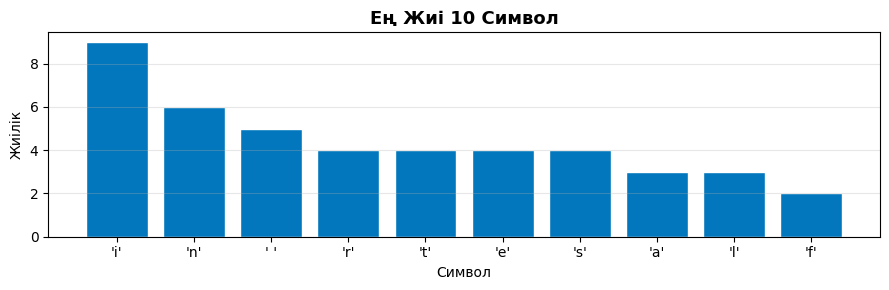

In [8]:
# ============================================================
### TODO ###
# Бірінші сөйлемдегі əрбір бірегей символдың жиілігін есептеңіз.
# Counter() пайдаланыңыз.
# Ең жиі 10 символды bar chart-та бейнелеңіз.
# ============================================================
char_freq = Counter(text)
top_chars = char_freq.most_common(10)

chars, freqs = zip(*top_chars)
plt.figure(figsize=(9, 3))
plt.bar([repr(c) for c in chars], freqs, color='#0277bd', edgecolor='white')
plt.title('Ең Жиі 10 Символ', fontsize=13, fontweight='bold')
plt.xlabel('Символ')
plt.ylabel('Жиілік')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 4-бөлім: Мəтінді Нормализациялау

Нормализация — мəтінді стандартты пішімге келтіру. Негізгі қадамдар:
- Кіші əріпке айналдыру (lowercasing)
- Тыныш белгілерді алу
- Сандарды алу немесе алмастыру
- Стоп-сөздерді алу
- Артық бос орындарды тазарту

In [9]:
def normalize_text(text, remove_stopwords=True):
    """
    Мəтінді нормализациялайтын функция.
    """
    # 1) Кіші əріпке айналдыру
    text = text.lower()

    # 2) URL-дерді алу
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3) Тыныш белгілерді алу
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4) Сандарды алу
    text = re.sub(r'\d+', '', text)

    # 5) Артық бос орындарды тазарту
    text = re.sub(r'\s+', ' ', text).strip()

    # 6) Токенизация
    tokens = word_tokenize(text)

    # 7) Стоп-сөздерді алу
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [t for t in tokens if t not in stop_words]

    return tokens

print("normalize_text() функциясы анықталды.")

normalize_text() функциясы анықталды.


In [10]:
# ============================================================
### TODO ###
# normalize_text() функциясын sample_texts-тің əр сөйлемімен қолданыңыз.
# Əр сөйлем үшін бастапқы сөз санын жəне нормализациядан
# кейінгі токен санын салыстырып шығарыңыз.
# ============================================================
print(f"{'Сөйлем':>5} {'Бастапқы':>10} {'Нормализациядан кейін':>22} {'Азаю':>8}")
print("-" * 50)

for i, sent in enumerate(sample_texts):
    original_tokens = sent.split()
    normalized = normalize_text(sent)
    reduction       = len(original_tokens) - len(normalized)
    print(f"{i+1:>5} {len(original_tokens):>10} {len(normalized):>22} {reduction:>8}")
    print(f"        Нормализация: {normalized}")

Сөйлем   Бастапқы  Нормализациядан кейін     Азаю
--------------------------------------------------
    1          6                      5        1
        Нормализация: ['artificial', 'intelligence', 'transforming', 'many', 'industries']
    2          7                      7        0
        Нормализация: ['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'text']
    3          7                      6        1
        Нормализация: ['machine', 'learning', 'algorithms', 'learn', 'patterns', 'data']
    4          6                      6        0
        Нормализация: ['deep', 'neural', 'networks', 'achieve', 'remarkable', 'performance']
    5          6                      5        1
        Нормализация: ['tokenization', 'converts', 'text', 'meaningful', 'units']


In [11]:
# Стоп-сөздер тізімін зерттейміз
stop_words = set(stopwords.words('english'))

print(f"Ағылшын стоп-сөздер саны: {len(stop_words)}")
print(f"Мысалдар: {sorted(list(stop_words))[:20]}")

Ағылшын стоп-сөздер саны: 198
Мысалдар: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [12]:
# ============================================================
### TODO ###
# Кастомды стоп-сөздер тізімін жасаңыз.
# Ағылшын стоп-сөздерге домен-специфик сөздер қосыңыз.
# custom_stops = {'also', 'however', 'therefore', 'thus', 'hence'}
# Кеңейтілген стоп-сөздермен нормализация жасаңыз.
# ============================================================
custom_stops   = {'also', 'however', 'therefore', 'thus', 'hence'}
extended_stops = stop_words | custom_stops   # custom_stops

sample = sample_texts[0]
tokens_standard = normalize_text(sample, remove_stopwords=True)

# Кеңейтілген стоп-сөздермен
tokens_ext = [t for t in normalize_text(sample, remove_stopwords=False)
              if t not in extended_stops]

print("Стандартты стоп-сөздер:", tokens_standard)
print(f"Кеңейтілген стоп-сөздер: {tokens_ext}")

Стандартты стоп-сөздер: ['artificial', 'intelligence', 'transforming', 'many', 'industries']
Кеңейтілген стоп-сөздер: ['artificial', 'intelligence', 'transforming', 'many', 'industries']


## 5-бөлім: Стемминг

**Стемминг** — сөздің жалғауын, жұрнағын алып, түбірге жақын формаға келтіру. Нəтиже əрдайым дұрыс сөз болмауы мүмкін.

Мысалы: `running → run`, `studies → studi`, `happiness → happi`

In [13]:
porter   = PorterStemmer()
snowball = SnowballStemmer('english')

test_words = [
    'running', 'runner', 'runs', 'ran',
    'studies', 'studying', 'studied', 'study',
    'happiness', 'happy', 'happily',
    'languages', 'language', 'linguistic'
]

print(f"{'Сөз':<15} {'Porter':<15} {'Snowball':<15}")
print("-" * 45)
for word in test_words:
    p = porter.stem(word)
    s = snowball.stem(word)
    print(f"{word:<15} {p:<15} {s:<15}")

Сөз             Porter          Snowball       
---------------------------------------------
running         run             run            
runner          runner          runner         
runs            run             run            
ran             ran             ran            
studies         studi           studi          
studying        studi           studi          
studied         studi           studi          
study           studi           studi          
happiness       happi           happi          
happy           happi           happi          
happily         happili         happili        
languages       languag         languag        
language        languag         languag        
linguistic      linguist        linguist       


In [14]:
# ============================================================
### TODO ###
# sample_texts-тің барлық сөздерін Porter стеммері арқылы өңдеңіз.
# Бастапқы сөз → стем жұптарын Counter арқылы санаңыз:
# қанша бірегей сөз бірдей стемге айналды?
# ============================================================
all_tokens = []
for sent in sample_texts:
    all_tokens.extend(normalize_text(sent, remove_stopwords=False))

stem_map = {}   # {stem: [сөздер тізімі]}
for token in all_tokens:
    stem = porter.stem(token)
    stem_map.setdefault(stem, set()).add(token)

# Бір стемге бірнеше сөз сəйкес келгендерді табыңыз
merged = {s: words for s, words in stem_map.items() if len(words) > 1}
print(f"Бір стемге бірнеше сөз сəйкес келген жағдайлар: {len(merged)}")
for stem, words in list(merged.items())[:5]:
    print(f"  '{stem}' ← {words}")

Бір стемге бірнеше сөз сəйкес келген жағдайлар: 1
  'learn' ← {'learn', 'learning'}


## 6-бөлім: Лемматизация

**Лемматизация** — сөздің лексикалық дұрыс негізгі формасын (лемманы) табу. Стеммингтен айырмасы: əрдайым нақты сөздік мəн береді.

Мысалы: `running → run`, `better → good`, `studies → study`

In [15]:
lemmatizer = WordNetLemmatizer()

# POS теги бойынша лемматизация əртүрлі нəтиже береді
# pos='v' — етістік, pos='n' — зат есім, pos='a' — сын есім
test_words_lem = [
    ('running',  'v'),
    ('studies',  'v'),
    ('better',   'a'),
    ('worse',    'a'),
    ('went',     'v'),
    ('languages','n'),
    ('mice',     'n'),
    ('flies',    'v'),
    ('flies',    'n'),
]

print(f"{'Сөз':<12} {'POS':<6} {'Лемма':<12} {'Стем (Porter)':<15}")
print("-" * 48)
for word, pos in test_words_lem:
    lemma = lemmatizer.lemmatize(word, pos=pos)
    stem  = porter.stem(word)
    print(f"{word:<12} {pos:<6} {lemma:<12} {stem:<15}")

Сөз          POS    Лемма        Стем (Porter)  
------------------------------------------------
running      v      run          run            
studies      v      study        studi          
better       a      good         better         
worse        a      bad          wors           
went         v      go           went           
languages    n      language     languag        
mice         n      mouse        mice           
flies        v      fly          fli            
flies        n      fly          fli            


In [16]:
# ============================================================
### TODO ###
# Стемминг пен лемматизацияны салыстырыңыз.
# comparison_words тізімін толтырып, екі əдісті бірден қолданыңыз.
# ============================================================
comparison_words = [
    'caring', 'cared', 'cares',
    'happily', 'happiness', 'happier',
    'wolves', 'women', 'children'
]

print(f"{'Сөз':<12} {'Porter Stem':<15} {'Лемма (n)':<15} {'Лемма (v)':<15}")
print("-" * 57)
for word in comparison_words:
    stem   = porter.stem(word)
    lem_n  = lemmatizer.lemmatize(word, pos='n')
    lem_v  = lemmatizer.lemmatize(word, pos='v')
    print(f"{word:<12} {stem:<15} {lem_n:<15} {lem_v:<15}")

Сөз          Porter Stem     Лемма (n)       Лемма (v)      
---------------------------------------------------------
caring       care            caring          care           
cared        care            cared           care           
cares        care            care            care           
happily      happili         happily         happily        
happiness    happi           happiness       happiness      
happier      happier         happier         happier        
wolves       wolv            wolf            wolves         
women        women           woman           women          
children     children        child           children       


## 7-бөлім: Subword Токенизация (BPE Принципі)

BERT, GPT сияқты заманауи модельдер **subword** токенизация пайдаланады:
- Сирек кездесетін сөздер бөлшектерге бөлінеді
- `tokenization → token ##iza ##tion`
- `unknown → un ##known`

Бұл тəсіл vocabulary өлшемін азайтып, OOV (Out-of-Vocabulary) мəселесін шешеді.

In [17]:
# BPE принципін қолмен демонстрациялаймыз
# Keras Tokenizer — word-level, бірақ принципті түсінуге ыңғайлы

keras_tokenizer = Tokenizer(num_words=100, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(sample_texts)

print("Vocabulary (алғашқы 20 сөз):")
word_index = keras_tokenizer.word_index
for word, idx in list(word_index.items())[:20]:
    print(f"  '{word}': {idx}")

Vocabulary (алғашқы 20 сөз):
  '<OOV>': 1
  'text': 2
  'artificial': 3
  'intelligence': 4
  'is': 5
  'transforming': 6
  'many': 7
  'industries': 8
  'natural': 9
  'language': 10
  'processing': 11
  'helps': 12
  'computers': 13
  'understand': 14
  'machine': 15
  'learning': 16
  'algorithms': 17
  'learn': 18
  'patterns': 19
  'from': 20


In [18]:
# ============================================================
### TODO ###
# keras_tokenizer.texts_to_sequences() арқылы sample_texts-ті
# индекстер тізбегіне айналдырыңыз.
# Əр сөйлем үшін: сөйлем → индекстер → pad_sequences пішімі.
# ============================================================
sequences = keras_tokenizer.texts_to_sequences(sample_texts)

print("Мəтін → Индекстер:")
for i, (sent, seq) in enumerate(zip(sample_texts, sequences)):
    print(f"  {i+1}: {sent[:50]}...")
    print(f"     → {seq}")
    print()

Мəтін → Индекстер:
  1: Artificial intelligence is transforming many indus...
     → [3, 4, 5, 6, 7, 8]

  2: Natural language processing helps computers unders...
     → [9, 10, 11, 12, 13, 14, 2]

  3: Machine learning algorithms learn patterns from da...
     → [15, 16, 17, 18, 19, 20, 21]

  4: Deep neural networks achieve remarkable performanc...
     → [22, 23, 24, 25, 26, 27]

  5: Tokenization converts text into meaningful units....
     → [28, 29, 2, 30, 31, 32]



In [19]:
# ============================================================
### TODO ###
# pad_sequences() арқылы тізбектерді бірдей ұзындыққа келтіріңіз.
# maxlen=15, padding='post', truncating='post' пайдаланыңыз.
# Нəтижені ndarray ретінде шығарыңыз.
# ============================================================
padded = pad_sequences(
    sequences,
    maxlen=15,
    padding='post',
    truncating='post'
)

print("Padding-тен кейінгі матрица:")
print(padded)
print("\nПішім:", padded.shape)

Padding-тен кейінгі матрица:
[[ 3  4  5  6  7  8  0  0  0  0  0  0  0  0  0]
 [ 9 10 11 12 13 14  2  0  0  0  0  0  0  0  0]
 [15 16 17 18 19 20 21  0  0  0  0  0  0  0  0]
 [22 23 24 25 26 27  0  0  0  0  0  0  0  0  0]
 [28 29  2 30 31 32  0  0  0  0  0  0  0  0  0]]

Пішім: (5, 15)


## 8-бөлім: Vocabulary Статистикасы

In [20]:
# Барлық нормализацияланған токендерді жинаймыз
all_normalized = []
for sent in sample_texts:
    all_normalized.extend(normalize_text(sent))

token_freq = Counter(all_normalized)

print(f"Бірегей токен саны: {len(token_freq)}")
print(f"Жалпы токен саны:   {sum(token_freq.values())}")
print(f"\nЕң жиі 10 токен:")
for token, freq in token_freq.most_common(10):
    print(f"  '{token}': {freq}")

Бірегей токен саны: 28
Жалпы токен саны:   29

Ең жиі 10 токен:
  'text': 2
  'artificial': 1
  'intelligence': 1
  'transforming': 1
  'many': 1
  'industries': 1
  'natural': 1
  'language': 1
  'processing': 1
  'helps': 1


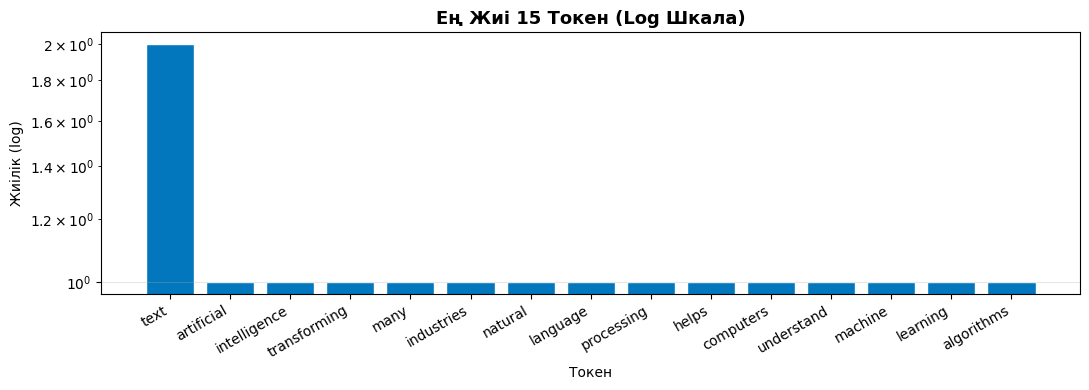

In [21]:
# ============================================================
### TODO ###
# Токен жиілігін log-шкалада bar chart-та бейнелеңіз.
# Ең жиі 15 токенді алыңыз.
# plt.yscale('log') пайдаланыңыз.
# ============================================================
top15  = token_freq.most_common(15)
words  = [w for w, _ in top15]
counts = [c for _, c in top15]

plt.figure(figsize=(11, 4))
plt.bar(words, counts, color='#0277bd', edgecolor='white')
plt.yscale('log')
plt.title('Ең Жиі 15 Токен (Log Шкала)', fontsize=13, fontweight='bold')
plt.xlabel('Токен')
plt.ylabel('Жиілік (log)')
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

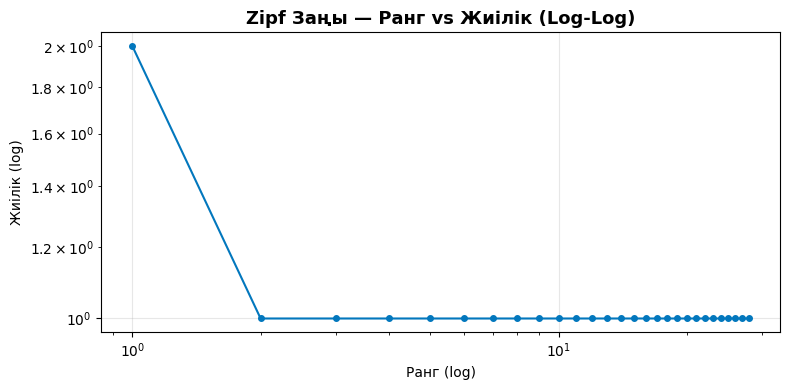

Zipf заңы: табиғи тілде жиіліктер геометриялық прогрессиямен азаяды.


In [22]:
# Zipf заңы: n-ші жиілікті сөз n-ге кері пропорционал жиілікке ие
# rank × frequency = константа (шамамен)
sorted_freqs = sorted(token_freq.values(), reverse=True)
ranks        = range(1, len(sorted_freqs) + 1)

plt.figure(figsize=(8, 4))
plt.loglog(list(ranks), sorted_freqs,
           marker='o', markersize=4, linewidth=1.5, color='#0277bd')
plt.title("Zipf Заңы — Ранг vs Жиілік (Log-Log)", fontsize=13, fontweight='bold')
plt.xlabel('Ранг (log)')
plt.ylabel('Жиілік (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Zipf заңы: табиғи тілде жиіліктер геометриялық прогрессиямен азаяды.")

## 9-бөлім: Tweet Tokenizer — Əлеуметтік Медиа Мəтіні

In [23]:
# ============================================================
### TODO ###
# Tweet мəтіндерін TweetTokenizer арқылы токенизациялаңыз.
# tweets тізімі берілген.
# Əр tweet үшін: word_tokenize() мен TweetTokenizer нəтижелерін
# салыстырыңыз.
# ============================================================
tweets = [
    "OMG!!! This is SO amazing 😍 #NLP #AI @OpenAI can't believe it!!",
    "Just finished my #DeepLearning course 🎉 Thanks @coursera :D",
    "RT @user: Check out this new model: https://t.co/xyz #ML",
]

tweet_tokenizer = TweetTokenizer(strip_handles=True, reduce_len=True)

for tweet in tweets:
    t_word  = word_tokenize(tweet)
    t_tweet = tweet_tokenizer.tokenize(tweet)
    print(f"Tweet: {tweet[:60]}...")
    print(f"  word_tokenize  : {t_word}")
    print(f"  TweetTokenizer : {t_tweet}")
    print()

Tweet: OMG!!! This is SO amazing 😍 #NLP #AI @OpenAI can't believe i...
  word_tokenize  : ['OMG', '!', '!', '!', 'This', 'is', 'SO', 'amazing', '😍', '#', 'NLP', '#', 'AI', '@', 'OpenAI', 'ca', "n't", 'believe', 'it', '!', '!']
  TweetTokenizer : ['OMG', '!', '!', '!', 'This', 'is', 'SO', 'amazing', '😍', '#NLP', '#AI', "can't", 'believe', 'it', '!', '!']

Tweet: Just finished my #DeepLearning course 🎉 Thanks @coursera :D...
  word_tokenize  : ['Just', 'finished', 'my', '#', 'DeepLearning', 'course', '🎉', 'Thanks', '@', 'coursera', ':', 'D']
  TweetTokenizer : ['Just', 'finished', 'my', '#DeepLearning', 'course', '🎉', 'Thanks', ':D']

Tweet: RT @user: Check out this new model: https://t.co/xyz #ML...
  word_tokenize  : ['RT', '@', 'user', ':', 'Check', 'out', 'this', 'new', 'model', ':', 'https', ':', '//t.co/xyz', '#', 'ML']
  TweetTokenizer : ['RT', ':', 'Check', 'out', 'this', 'new', 'model', ':', 'https://t.co/xyz', '#ML']



## 10-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** `split()`, regex жəне `word_tokenize()` əдістерінің нəтижелері нəлер бойынша ерекшеленеді? Қай жағдайда қайсысын қолдану дұрыс?

> split() — ең қарапайым, тек бос орын бойынша бөледі.
regex — тыныс белгілерін басқаруға мүмкіндік береді.
word_tokenize() — тілдік ерекшеліктерді жақсы өңдейді, NLP үшін ең қолайлы.

**Сұрақ 2.** Стемминг пен лемматизацияның практикалық айырмасы неде? Іздеу жүйесі үшін қайсысы ыңғайлы?

> Стемминг сөзді қысқартады, бірақ кейде дұрыс сөз шықпайды (studies → studi).
Лемматизация сөздің нақты сөздік формасын береді (studies → study).
Іздеу жүйелерінде көбіне стемминг жылдамдығына байланысты жиі қолданылады.

**Сұрақ 3.** Стоп-сөздерді алу əрдайым пайдалы ма? Стоп-сөз маңызды болатын NLP міндеті бар ма?

> Жоқ, әрдайым пайдалы емес. Мысалы, машиналық аудармада немесе мәтін генерациясында стоп-сөздер маңызды ақпарат тасымалдайды.

**Сұрақ 4.** Subword токенизация OOV (Out-of-Vocabulary) мəселесін қалай шешеді?

> Subword токенизация белгісіз сөзді бірнеше таныс бөліктерге бөледі. Сондықтан жаңа сөздер кездессе де модель оларды өңдей алады.

**Сұрақ 5.** Zipf заңы не туралы айтады? Бұл NLP-де vocabulary жасауға қалай əсер етеді?

> Zipf заңы бойынша бірнеше сөз өте жиі кездеседі, ал көп сөздер сирек кездеседі. Сондықтан vocabulary жасағанда ең жиі сөздерді таңдау тиімді болады.

## Қорытынды

Осы зертханада сіз сөз, символ жəне сөйлем деңгейіндегі токенизацияны салыстырдыңыз, мəтінді нормализациялауды (кіші əріп, стоп-сөз, тыныш белгілер) іске асырдыңыз, стемминг пен лемматизацияның практикалық айырмасын байқадыңыз, Keras Tokenizer арқылы мəтінді индекстерге айналдырдыңыз, жəне Zipf заңын нақты деректерде тексердіңіз.

<div style="background-color:#e1f5fe; border-left:5px solid #0277bd; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 2 — Bag of Words жəне TF-IDF: токендерді санды векторға айналдыру.
</div>